In [1]:
import pandas as pd

In [2]:
!ls /var/log/

alternatives.log  btmp	    faillog	    lastlog  runit
apt		  dpkg.log  fontconfig.log  private  wtmp
bootstrap.log	  exim4     journal	    README


In [7]:
dpkg=pd.read_csv('/var/log/dpkg.log',delimiter=' ',header=None,usecols=[0, 1,2,3,4])#,skipfooter=2,engine='python'

In [10]:
def data_process(df):
    return (df
            .rename(columns={0:'date',1:'time',2:'type',3:'arg1',4:'arg2'})
           )

In [11]:
dpkg.pipe(data_process)

,date,time,type,arg1,arg2
0,2025-02-04,21:01:31,startup,archives,install
1,2025-02-04,21:01:31,install,base-passwd:amd64,<none>
2,2025-02-04,21:01:31,status,half-installed,base-passwd:amd64
3,2025-02-04,21:01:31,status,unpacked,base-passwd:amd64
4,2025-02-04,21:01:31,configure,base-passwd:amd64,3.6.1
...,...,...,...,...,...
16185,2026-05-29,21:05:08,status,half-configured,man-db:amd64
16186,2026-05-29,21:05:09,status,installed,man-db:amd64
16187,2026-05-29,21:05:09,trigproc,desktop-file-utils:amd64,0.26-1
16188,2026-05-29,21:05:09,status,half-configured,desktop-file-utils:amd64


<AxesSubplot: ylabel='type'>

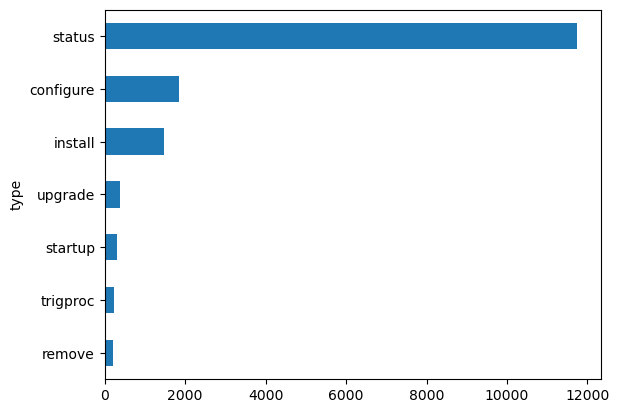

In [20]:
dpkg.pipe(data_process).groupby('type').count()['date'].sort_values().plot(kind='barh')

<AxesSubplot: ylabel='arg1'>

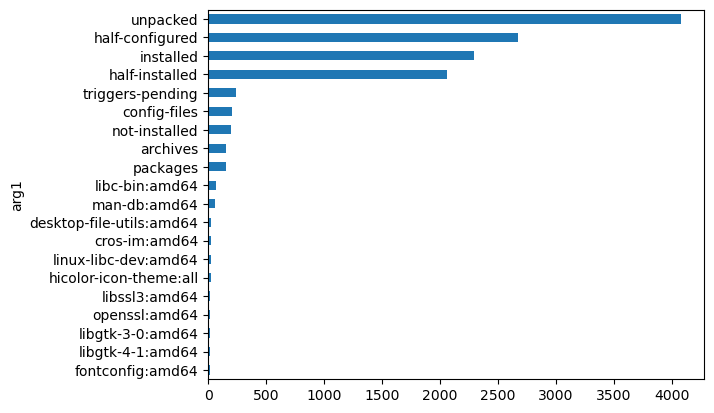

In [26]:
(dpkg
 .pipe(data_process)
 .groupby('arg1')
 .count()
 ['date']
 .sort_values(ascending=False)
 .iloc[0:20]
 .sort_values(ascending=True) 
 .plot(kind='barh')
)

<AxesSubplot: ylabel='arg2'>

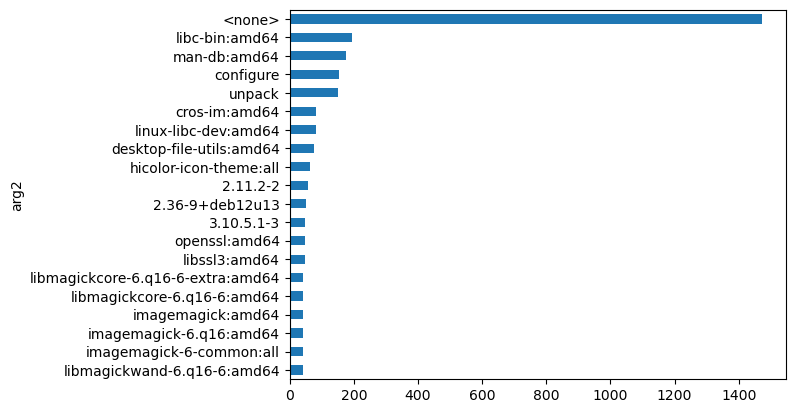

In [33]:
(dpkg
 .pipe(data_process)
 .groupby('arg2')
 .count()
 ['date']
 .sort_values(ascending=False)
 .iloc[0:20]
 .sort_values(ascending=True) 
 .plot(kind='barh')
)